# 05 — Approach II: rule-based typing

Current rule: a candidate cell type is positive when **≥3 available marker genes have raw count >0**. Multiple positive panels → `Ambiguous`; no positive panel → `Unassigned`. The same UMAP coordinates as Approach I are retained.

In [1]:
from pathlib import Path
import sys, os

# Notebook lives in PROJECT_ROOT/jupyter/.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "jupyter" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Python:", sys.executable)
assert (PROJECT_ROOT / "scripts").exists(), "Run this notebook from PROJECT_ROOT/jupyter or PROJECT_ROOT."

PROJECT_ROOT: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python: /home/jqu/.conda/envs/spatialdata/bin/python


In [ ]:
%run ../scripts/04d_approach_ii_rule_based.py

## Inspect rule results

In [2]:
import scanpy as sc, pandas as pd
from IPython.display import display
a=sc.read_h5ad(PROJECT_ROOT/"results/FOV46/GSM9046088_FOV46_approach_i_ii.h5ad")
display(a.obs["cell_type_rule"].value_counts(dropna=False).to_frame("n"))
display(pd.read_csv(PROJECT_ROOT/"results/FOV46/tables/rule_marker_availability.csv"))

,n
cell_type_rule,
Unassigned,331
Ambiguous,176
Macrophage,159
Plasma_cell,117
Fibroblast,91
Epithelial,63
Endothelial,1


,cell_type,n_requested,n_present,min_positive_genes,available,present,missing
0,Epithelial,4,4,3,True,"EPCAM,KRT8,KRT18,KRT19",NaN
1,AT1,4,1,3,False,CAV1,"AGER,CAV2,PDPN"
2,AT2,5,0,3,False,NaN,"SFTPA1,SFTPA2,SFTPB,SFTPC,NAPSA"
3,Tumor_epithelial,5,3,3,True,"CEACAM6,KRT17,MKI67","CEACAM5,MUC1"
4,T_cell,4,2,3,False,"CD3D,CD3E","TRAC,CD247"
5,B_cell,4,3,3,True,"MS4A1,CD79A,CD37",CD79B
6,Plasma_cell,4,3,3,True,"MZB1,JCHAIN,IGHG1",SDC1
7,Myeloid,4,3,3,True,"TYROBP,FCER1G,AIF1",LST1
8,Macrophage,5,5,3,True,"C1QA,C1QB,C1QC,APOE,CD68",NaN
9,Endothelial,4,3,3,True,"PECAM1,VWF,KDR",EMCN


## UMAP: Approach I vs II with the same theme

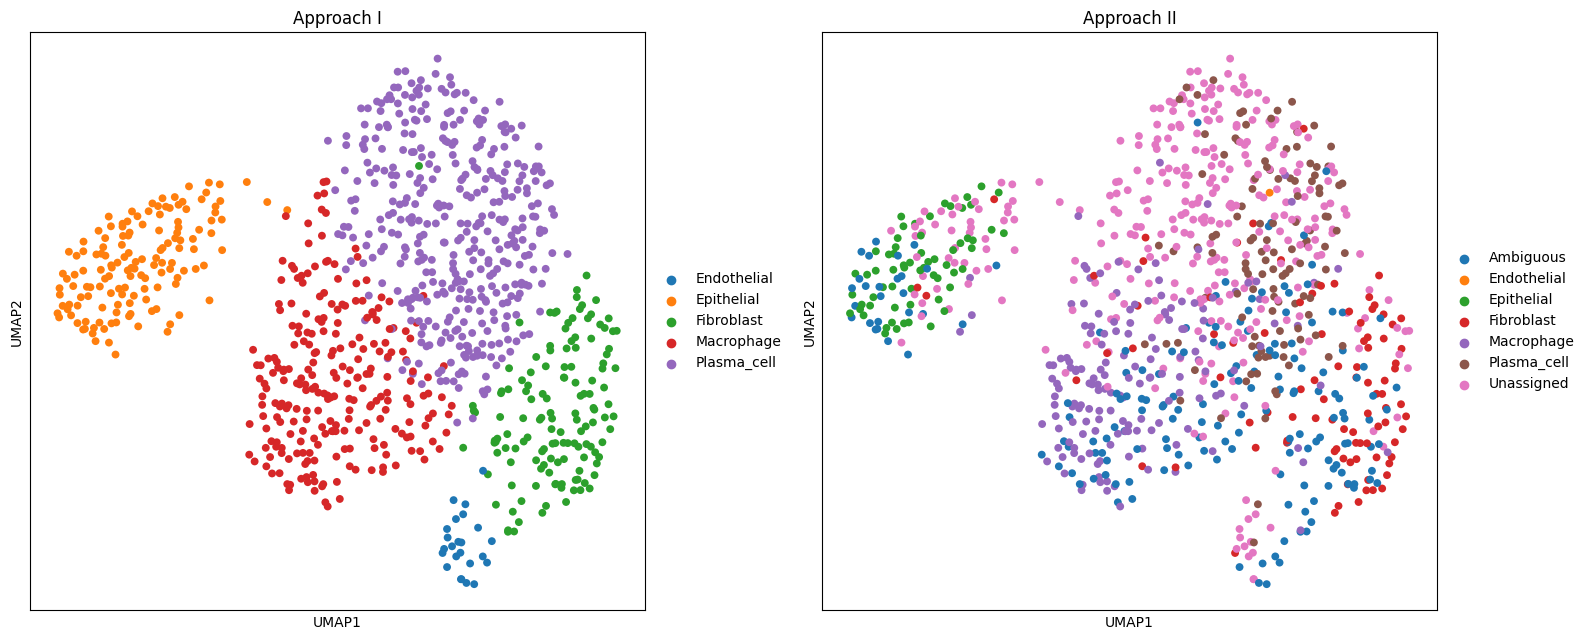

In [3]:
from src.plotting import plot_umap_annotation
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(16,6.5))
plot_umap_annotation(a,"cell_type_scanpy",None,title="Approach I",ax=axes[0])
plot_umap_annotation(a,"cell_type_rule",None,title="Approach II",ax=axes[1])
plt.tight_layout(); plt.show()